In [11]:
#load packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#directories of files
pop_map = "/scicore/home/muellepi/marmor0000/albopictus_ddRADseq/popmap_albo.txt"
indv_table = "/scicore/home/muellepi/marmor0000/albopictus_ddRADseq/snp_filtering/040_FMi_and_LD_filter/FM_0.65_mD_3_MD_30_FMi_0.3/LD_thinindv_metrics.csv"
evec = "/scicore/home/muellepi/marmor0000/albopictus_ddRADseq/snp_filtering/040_FMi_and_LD_filter/FM_0.65_mD_3_MD_30_FMi_0.3/LD_thin.eigenvec"
evals = "/scicore/home/muellepi/marmor0000/albopictus_ddRADseq/snp_filtering/040_FMi_and_LD_filter/FM_0.65_mD_3_MD_30_FMi_0.3/LD_thin.eigenval"

In [12]:
#summarize individuals per population
indv_table = pd.read_table(indv_table, sep=',', header=0)
indv_table.index = indv_table['INDV']
indv_table['population'].value_counts()

population
Switzerland        41
Malaysia           34
Spain              33
Indonesia          31
Hongkong           28
Italy              23
France             15
Taiwan             14
Guangzhou          10
Croatia             9
TurkeyWest          8
TurkeyEast          8
Greece              7
LaReunion           7
Albania             6
USA                 6
Vietnam             6
Cameroon            6
Brasil              5
Serbia              5
Vanuatu             5
ChristmasIsland     4
Slovenia            4
Malta               4
Israel              4
Montenegro          4
Mauritius           3
SriLanka            3
Fiji                2
Philippines         2
Singapore           2
Germany             2
Liechtenstein       1
Bulgaria            1
Name: count, dtype: int64

# PCA all samples

In [17]:
evec = pd.read_csv(evec, sep=r"\s+", header=None)
evals = np.loadtxt(evals)

evec.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, evec.shape[1] - 1)]

In [18]:
#load population map and add column names
popmap = pd.read_csv(pop_map, sep=r"\s+", header=None)
popmap.columns = ["IID", "pop", "native_invasive"]

#merge PCA and metadata
df = evec.merge(popmap, on="IID", how="left")
df["pop"].isna().value_counts()
df.head()

,FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC293,PC294,PC295,PC296,PC297,PC298,PC299,PC300,pop,native_invasive
0,ALKR1,ALKR1,0.027788,-0.014582,0.000845,0.000595,-0.011904,0.004535,-0.006837,-0.002398,...,0.076489,-0.147445,-0.149653,0.039728,0.091477,-0.107463,-0.098936,-0.018690,Albania,invaded
1,ALKR3,ALKR3,0.038858,-0.028729,0.000772,-0.000964,-0.005917,0.009698,-0.000282,-0.007598,...,-0.102357,0.122907,0.035212,-0.085584,-0.023149,0.092794,-0.011621,0.067831,Albania,invaded
2,ALKR5,ALKR5,0.032806,-0.026515,-0.002688,-0.002239,-0.007445,0.015405,-0.003322,-0.010715,...,0.001614,0.024412,0.074011,-0.120727,-0.079468,0.095398,0.072011,0.030819,Albania,invaded
3,ALSH2,ALSH2,0.028035,-0.018835,0.000149,-0.002911,-0.004194,0.000941,-0.015017,-0.006634,...,-0.039209,-0.011874,0.030014,0.091079,0.074852,0.043791,0.011994,0.016466,Albania,invaded
4,ALTI3,ALTI3,0.035132,-0.028524,-0.002271,-0.003912,-0.009075,0.031994,-0.002436,-0.009041,...,0.076400,0.033827,0.033804,-0.017497,-0.055106,-0.128817,-0.026788,0.036467,Albania,invaded


In [19]:
pc_var = evals / evals.sum() * 100

xlab_pc1 = f"PC1 ({pc_var[0]:.1f}%)"
ylab_pc2 = f"PC2 ({pc_var[1]:.1f}%)"

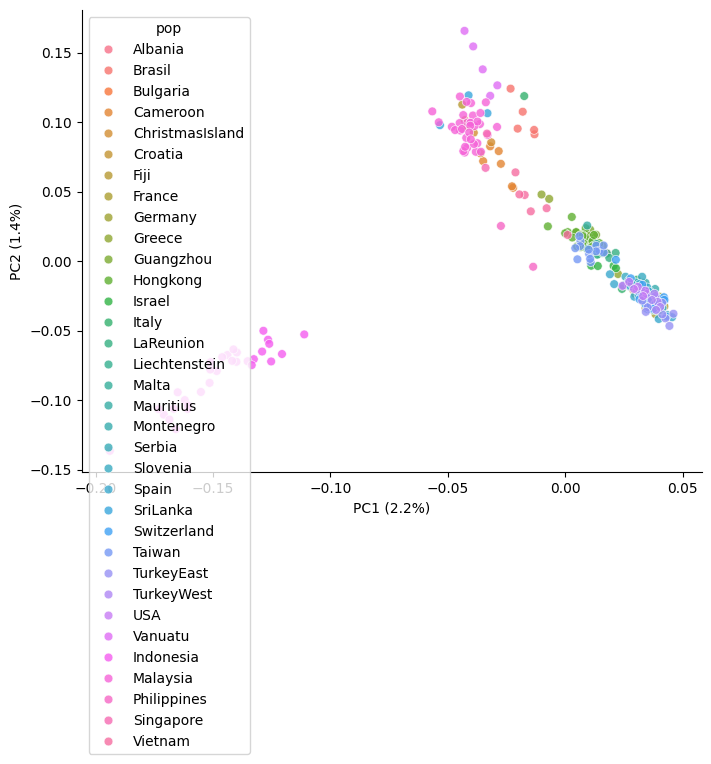

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="pop",
    s=40,
    alpha=0.8
)

plt.xlabel(xlab_pc1)
plt.ylabel(ylab_pc2)
#ax.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")

#plt.legend(title="Population", loc="right")
#plt.gca().set_facecolor("white")

sns.despine()
plt.show()

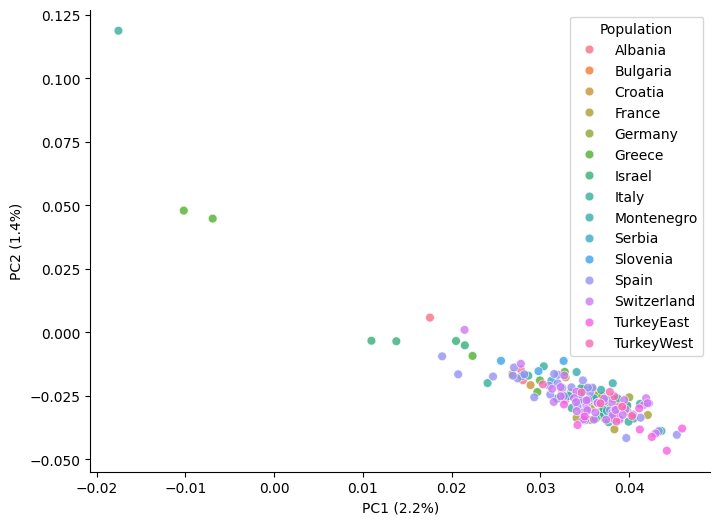

In [45]:
exclude =["USA", "Malta", "Philippines", "Liechtenstein", "Indonesia", "Vanuatu", "Malaysia", "Fiji", "Cameroon", "ChristmasIsland", "Guangzhou", "Hongkong", "LaReunion", "Mauritius", "SriLanka", "Taiwan", "Singapore", "Vietnam", "Brasil"]
df_no_id = df[~df["pop"].isin(exclude)]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_no_id,
    x="PC1",
    y="PC2",
    hue="pop",
    s=40,
    alpha=0.8
)

plt.xlabel(xlab_pc1)
plt.ylabel(ylab_pc2)
plt.legend(title="Population", loc="upper right")
plt.gca().set_facecolor("white")

sns.despine()
plt.show()